![Universidad Espíritu Santo](https://raw.githubusercontent.com/andresrubiop/miar0525-estudiantes/main/utils/logo-uees-color.png)

<div style="background:#821436;color:#FFFFFF;padding:14px 18px;border-radius:10px;margin:6px 0 12px 0"><div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;opacity:.9">Aprendizaje Automático · MIAR0525 · Semana 4 · Versión resuelta · referencia</div><div style="font-size:22px;font-weight:700;margin-top:4px">E4.1 · Calidad de datos y ficha de datos</div><div style="font-size:12px;opacity:.9;margin-top:4px">Postgrado · Maestría en Inteligencia Artificial · UEES</div></div>

| | |
|---|---|
| **Objetivo** | Diagnosticar la calidad de un conjunto de datos (faltantes y su mecanismo, duplicados, valores tope, inconsistencias, representación) y documentarlo en una ficha de datos (*Datasheet*). |
| **Resultado de aprendizaje** | RDA1 y RDA2 · competencias CG-G1, CE-G1 y CE-G2 (según el sílabo) |
| **Duración** | ≈ 4 h |
| **Teoría** | Manual M4 §1 y §5 · Animación A4.2 · Video V4.1 · Gebru et al. (2021), *Datasheets for Datasets* (BC6) |
| **Datos** | Sintéticos · **Adult** (OpenML 1590: 48 842 personas del censo de EE. UU. de 1994; objetivo: ingreso anual > 50 000 USD) |

**Niveles:** 1 · mecanismos de faltantes y funciones de auditoría desde cero → 2 · un `reporte_calidad(df)` reutilizable → 3 · diagnóstico de Adult y su ficha de datos → 4 · reto: ¿para qué **no** debería usarse este dataset hoy?

## 0 · Configuración

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from cycler import cycler
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 2026
UEES = {"vino": "#821436", "azul": "#1F6F8B", "ocre": "#C28E0E", "verde": "#3A7D44", "gris": "#77787B"}
plt.rcParams.update({
    "axes.prop_cycle": cycler(color=list(UEES.values())), "axes.titlecolor": UEES["vino"],
    "axes.titleweight": "bold", "axes.edgecolor": UEES["gris"], "axes.grid": True, "grid.color": "#EEE8EA",
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110, "legend.frameon": False,
})
print(f"scikit-learn {sklearn.__version__} · pandas {pd.__version__} · semilla {SEED}")

scikit-learn 1.9.1 · pandas 3.0.5 · semilla 2026


## Nivel 1 · Desde cero (prelaboratorio)

### 1.1 Por qué importa el mecanismo de los faltantes
Un valor faltante no es solo un hueco: **por qué falta** decide si podemos ignorarlo.
- **MCAR** (*missing completely at random*): falta al azar, sin relación con nada. Borrar esas filas no sesga, solo reduce la muestra.
- **MAR** (*missing at random*): la probabilidad de faltar depende de **otras variables observadas** (por ejemplo, los jóvenes reportan menos su ingreso). Se puede corregir usando esas variables.
- **MNAR** (*missing not at random*): depende del **propio valor** que falta (quienes más ganan no lo declaran). Con los datos observados no se puede corregir.

Simulamos 5 000 empleados con edad e ingreso mensual y borramos el ingreso con cada mecanismo.

In [2]:
rng = np.random.default_rng(SEED)
n = 5000
edad = rng.integers(20, 65, n)
ingreso = 900 + 45 * (edad - 20) + rng.normal(0, 400, n)          # el ingreso sube con la edad
verdad = ingreso.mean()
joven = edad < 35


def mascara_mcar(r):
    return r.random(n) < 0.30                                          # 30 % de faltantes al azar


def mascara_mar(r):
    # TODO: la probabilidad de faltar depende de la edad (observada): 50 % si edad < 35 y 15 % si no.
    return r.random(n) < np.where(joven, 0.50, 0.15)


def mascara_mnar(r):
    # TODO: la probabilidad de faltar depende del propio ingreso: 1 / (1 + exp(−(ingreso − 2 400) / 250)).
    return r.random(n) < 1 / (1 + np.exp(-(ingreso - 2400) / 250))


def media_estratificada(valores, falta, estratos):
    """Media de cada estrato con los datos observados, ponderada por el peso del estrato en la población."""
    # TODO: para cada estrato, promedia los valores no faltantes y pondera por la proporción de filas del estrato.
    return sum(valores[(estratos == e) & ~falta].mean() * np.mean(estratos == e) for e in np.unique(estratos))


filas = []
for nombre, fn in (("MCAR", mascara_mcar), ("MAR (edad)", mascara_mar), ("MNAR (ingreso)", mascara_mnar)):
    falta = fn(np.random.default_rng(SEED + 1))
    filas.append({"mecanismo": nombre, "% faltante": 100 * falta.mean(), "media con filas completas": ingreso[~falta].mean(),
                  "media estratificada por edad": media_estratificada(ingreso, falta, joven), "media verdadera": verdad})
tabla_mec = pd.DataFrame(filas).set_index("mecanismo").round(1)
tabla_mec

,% faltante,media con filas completas,media estratificada por edad,media verdadera
mecanismo,,,,
MCAR,29.5,1906.6,1904.1,1899.6
MAR (edad),27.1,2020.3,1906.4,1899.6
MNAR (ingreso),27.5,1620.4,1704.0,1899.6


**Qué observar.** Con MCAR, borrar filas deja la media casi intacta. Con MAR la media de las filas completas se sesga hacia arriba (faltan sobre todo los jóvenes, que ganan menos), pero **estratificar por edad** la recupera. Con MNAR ni borrar ni estratificar funciona: faltan justo los ingresos altos. En datos reales rara vez sabemos cuál es el mecanismo, pero sí podemos comprobar si la tasa de faltantes **cambia entre grupos** (entonces no es MCAR).

### 1.2 Funciones de auditoría
Un conjunto de juguete con problemas sembrados a propósito: faltantes que dependen del grupo, un duplicado exacto, un valor imposible, un tope en 99 y una categoría rara.

In [3]:
juguete = pd.DataFrame({
    "id": range(1, 13),
    "grupo": ["A", "A", "A", "A", "A", "A", "B", "B", "B", "B", "B", "B"],
    "edad": [34, 41, 29, 52, 38, 45, 31, 27, 44, -3, 36, 33],
    "horas": [40, 38, 99, 45, 99, 40, 99, 99, 42, 99, 40, 99],
    "cargo": ["ing", "ing", "tec", "ger", "tec", "ing", None, None, "tec", None, "ing", "otro"],
})
juguete.loc[12] = juguete.loc[1].to_list()          # duplicado exacto de la fila 1 (mismo id)


def faltantes_por_grupo(df, columna, grupo):
    # TODO: proporción de faltantes de `columna` dentro de cada valor de `grupo` (una Serie).
    return df[columna].isna().groupby(df[grupo]).mean()


def acumulacion_en_maximo(serie, minimo=3, veces=3):
    """¿Hay demasiadas filas en el valor máximo? (tope de encuesta o código centinela como 99 o 99999)."""
    # TODO: cuenta las filas en el máximo y en el segundo valor más alto; devuelve True si las del máximo
    #       son al menos `minimo` y al menos `veces` las del segundo valor.
    conteo = serie.value_counts().sort_index()
    if len(conteo) < 2:
        return False
    return bool(conteo.iloc[-1] >= minimo and conteo.iloc[-1] >= veces * conteo.iloc[-2])


print("faltantes de cargo por grupo:", faltantes_por_grupo(juguete, "cargo", "grupo").round(2).to_dict())
print("duplicados exactos:", int(juguete.duplicated().sum()))
print("edades imposibles (< 0 o > 110):", int(((juguete.edad < 0) | (juguete.edad > 110)).sum()))
print("¿acumulación en el máximo de horas?", acumulacion_en_maximo(juguete.horas), "· ¿y de edad?", acumulacion_en_maximo(juguete.edad))
print("categorías con menos de 2 filas:", juguete.cargo.value_counts()[lambda s: s < 2].index.tolist())

faltantes de cargo por grupo: {'A': 0.0, 'B': 0.5}
duplicados exactos: 1
edades imposibles (< 0 o > 110): 1
¿acumulación en el máximo de horas? True · ¿y de edad? False
categorías con menos de 2 filas: ['ger', 'otro']


## Nivel 2 · Un informe de calidad reutilizable

Juntamos las piezas en `reporte_calidad(df, grupo)`: una fila por columna con su tipo, % de faltantes, número de valores distintos y **alertas**. La función no corrige nada: señala qué revisar y documentar.

In [4]:
def reporte_calidad(df, grupo=None, categorias_raras=20, tope_minimo=10):
    filas = []
    for c in df.columns:
        s = df[c]
        alertas = []
        falt = s.isna().mean()
        if s.nunique(dropna=True) <= 1:
            alertas.append("constante")
        if pd.api.types.is_numeric_dtype(s):
            if acumulacion_en_maximo(s.dropna(), minimo=tope_minimo, veces=5):
                alertas.append(f"acumulación en el máximo ({s.max():g})")
        else:
            conteo = s.value_counts()
            raras = int((conteo < categorias_raras).sum())
            if raras:
                alertas.append(f"{raras} categoría(s) con < {categorias_raras} filas")
            if s.nunique() > 30:
                alertas.append("alta cardinalidad")
        if grupo is not None and c != grupo and falt > 0:
            por_grupo = s.isna().groupby(df[grupo], observed=True).mean()
            # TODO: si la tasa de faltantes máxima entre grupos es al menos el doble de la mínima, agrega la alerta
            #       "faltantes desiguales por <grupo> (máx/mín = …)".
            if por_grupo.min() > 0 and por_grupo.max() / por_grupo.min() >= 2:
                alertas.append(f"faltantes desiguales por {grupo} (máx/mín = {por_grupo.max() / por_grupo.min():.1f})")
            elif por_grupo.min() == 0:
                alertas.append(f"faltantes solo en algunos grupos de {grupo}")
        filas.append({"columna": c, "tipo": str(s.dtype), "% faltantes": round(100 * falt, 2), "distintos": s.nunique(),
                      "alertas": "; ".join(alertas)})
    rep = pd.DataFrame(filas).set_index("columna")
    rep.attrs["duplicados"] = int(df.duplicated().sum())
    return rep


rep_j = reporte_calidad(juguete, grupo="grupo", categorias_raras=2, tope_minimo=3)
print("duplicados exactos:", rep_j.attrs["duplicados"])
rep_j

duplicados exactos: 1


,tipo,% faltantes,distintos,alertas
columna,,,,
id,int64,0.00,12,
grupo,str,0.00,2,
edad,int64,0.00,12,
horas,int64,0.00,5,acumulación en el máximo (99)
cargo,str,23.08,4,2 categoría(s) con < 2 filas; faltantes solo e...


In [5]:
assert rep_j.attrs["duplicados"] == 1
assert "acumulación en el máximo" in rep_j.loc["horas", "alertas"]
assert "faltantes solo en algunos grupos" in rep_j.loc["cargo", "alertas"]
assert "categoría" in rep_j.loc["cargo", "alertas"]
print("✓ Tu reporte detecta los problemas sembrados (el valor imposible de edad lo detectan las reglas de dominio del nivel 1)")

✓ Tu reporte detecta los problemas sembrados (el valor imposible de edad lo detectan las reglas de dominio del nivel 1)


## Nivel 3 · Diagnóstico de Adult y su ficha de datos

Adult se extrajo del censo de EE. UU. de **1994** y se usa desde hace décadas como referencia en aprendizaje automático, incluso en investigación sobre equidad. Veamos qué hay dentro antes de entrenar nada.

In [6]:
from sklearn.datasets import fetch_openml

adult = fetch_openml(data_id=1590, as_frame=True).frame        # en esta versión los "?" ya vienen como NaN
adult["ingreso_alto"] = (adult["class"] == ">50K").astype(int)
adult["grupo_edad"] = pd.cut(adult["age"], [0, 24, 34, 44, 54, 64, 120], labels=["17–24", "25–34", "35–44", "45–54", "55–64", "65+"])
print(f"{len(adult)} filas · {adult.shape[1] - 3} variables · {adult['ingreso_alto'].mean():.1%} con ingreso > 50K")
rep_adult = reporte_calidad(adult.drop(columns=["class", "grupo_edad"]), grupo="sex")
print("duplicados exactos:", rep_adult.attrs["duplicados"])
rep_adult

48842 filas · 14 variables · 23.9% con ingreso > 50K
duplicados exactos: 52


,tipo,% faltantes,distintos,alertas
columna,,,,
age,int64,0.00,74,acumulación en el máximo (90)
workclass,category,5.73,8,1 categoría(s) con < 20 filas
fnlwgt,int64,0.00,28523,
education,category,0.00,16,
education-num,int64,0.00,16,
marital-status,category,0.00,7,
occupation,category,5.75,14,1 categoría(s) con < 20 filas
relationship,category,0.00,6,
race,category,0.00,5,


### 3.1 ¿Los faltantes son MCAR?

In [7]:
completas = adult.dropna(subset=["workclass", "occupation", "native-country"])
fila_falt = adult[["workclass", "occupation", "native-country"]].isna().any(axis=1)
print(f"filas con algún faltante: {fila_falt.sum()} ({fila_falt.mean():.2%}) · workclass y occupation faltan juntas en {(adult.workclass.isna() & adult.occupation.isna()).sum()} filas")
print(f"occupation falta en {adult.loc[adult.workclass == 'Never-worked', 'occupation'].isna().sum()} de las "
      f"{(adult.workclass == 'Never-worked').sum()} personas que nunca trabajaron (faltante estructural: no aplica)")
tabla_falt = pd.DataFrame({
    "faltante en occupation": adult["occupation"].isna().groupby(adult["grupo_edad"], observed=True).mean(),
    "filas perdidas con dropna": 1 - completas["grupo_edad"].value_counts() / adult["grupo_edad"].value_counts(),
}).mul(100).round(1)
display(tabla_falt)
perdida = {g: 1 - completas[g].value_counts() / adult[g].value_counts() for g in ("sex", "race")}
print("filas perdidas con dropna por sexo:", perdida["sex"].mul(100).round(1).to_dict())
print("filas perdidas con dropna por raza:", perdida["race"].mul(100).round(1).to_dict())
print(f"tasa de ingreso alto: {adult['ingreso_alto'].mean():.3f} con todas las filas · {completas['ingreso_alto'].mean():.3f} tras dropna")

filas con algún faltante: 3620 (7.41%) · workclass y occupation faltan juntas en 2799 filas
occupation falta en 10 de las 10 personas que nunca trabajaron (faltante estructural: no aplica)


,faltante en occupation,filas perdidas con dropna
grupo_edad,,
17–24,12.3,13.3
25–34,3.2,5.1
35–44,2.1,4.1
45–54,2.6,4.1
55–64,8.1,9.8
65+,24.0,25.2


filas perdidas con dropna por sexo: {'Male': 6.5, 'Female': 9.2}
filas perdidas con dropna por raza: {'White': 6.8, 'Black': 9.8, 'Asian-Pac-Islander': 14.2, 'Amer-Indian-Eskimo': 7.4, 'Other': 13.1}
tasa de ingreso alto: 0.239 con todas las filas · 0.248 tras dropna


**Qué observar.** Los faltantes **no** son MCAR: `occupation` falta en el 12 % de los jóvenes de 17–24 años y en el 24 % de los mayores de 64 (estudiantes y jubilados), frente al 2–3 % de las edades intermedias. Un `dropna()` sin pensar borra una de cada cuatro personas mayores de 64, el 14 % de los asiático-pacíficos y el 9 % de las mujeres, y sube la tasa de ingreso alto. Parte de los faltantes son **estructurales** (quien nunca trabajó no tiene ocupación): no son errores, son "no aplica", y se codifican como categoría propia.

### 3.2 Topes, duplicados, redundancias y proxies

In [8]:
for col, tope in (("capital-gain", 99999), ("hours-per-week", 99), ("age", 90)):
    print(f"{col}: {int((adult[col] == tope).sum())} filas en {tope} (el siguiente valor tiene {int(adult.loc[adult[col] < tope, col].value_counts().sort_index().iloc[-1])})")
print(f"duplicados exactos: {adult.drop(columns=['ingreso_alto', 'grupo_edad']).duplicated().sum()} · "
      f"filas idénticas salvo fnlwgt: {adult.drop(columns=['fnlwgt', 'ingreso_alto', 'grupo_edad']).duplicated().sum()}")
print("education ↔ education-num es 1 a 1:", bool(adult.groupby("education", observed=True)["education-num"].nunique().max() == 1))
parentesco = pd.crosstab(adult["relationship"], adult["sex"])
display(parentesco)

capital-gain: 244 filas en 99999 (el siguiente valor tiene 3)
hours-per-week: 137 filas en 99 (el siguiente valor tiene 14)
age: 55 filas en 90 (el siguiente valor tiene 2)


duplicados exactos: 52 · filas idénticas salvo fnlwgt: 6374
education ↔ education-num es 1 a 1: True


sex,Female,Male
relationship,,
Husband,1,19715
Not-in-family,5870,6713
Other-relative,689,817
Own-child,3376,4205
Unmarried,3928,1197
Wife,2328,3


**Qué observar.**
- `capital-gain` = 99 999 (244 filas), `hours-per-week` = 99 y `age` = 90 son **topes de la encuesta**: el valor real puede ser mayor. Tratarlos como números exactos distorsiona promedios y modelos.
- Solo 52 filas son duplicados exactos, pero 6 374 son idénticas salvo `fnlwgt`: con variables tan gruesas, dos personas distintas pueden coincidir. **No todo duplicado es un error**; hay que entender cómo se generaron los datos. `fnlwgt` es un **peso muestral** del censo (cuántas personas representa la fila), no una característica de la persona.
- `education` y `education-num` dicen lo mismo: una sobra.
- `relationship` codifica el sexo: "Husband" es casi siempre hombre y "Wife" mujer (con 1 y 3 registros inconsistentes). Aunque quitemos `sex`, el modelo lo "ve" por un **proxy**.

### 3.3 Representación y tasas base

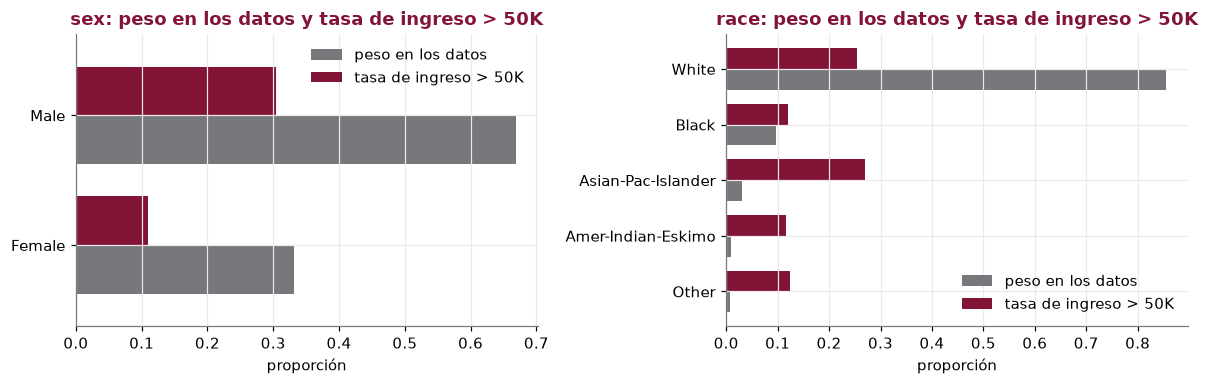

tasa de ingreso alto por sexo: {'Female': 0.109, 'Male': 0.304}
tasa de ingreso alto por raza: {'Amer-Indian-Eskimo': 0.117, 'Asian-Pac-Islander': 0.269, 'Black': 0.121, 'Other': 0.123, 'White': 0.254}
personas nacidas en EE. UU.: 89.7% · países con menos de 20 personas: 2


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, g in zip(axes, ("sex", "race")):
    t = adult.groupby(g, observed=True).agg(proporcion=("ingreso_alto", "size"), tasa=("ingreso_alto", "mean"))
    t["proporcion"] /= len(adult)
    t = t.rename(columns={"proporcion": "peso en los datos", "tasa": "tasa de ingreso > 50K"})
    t.sort_values("peso en los datos").plot.barh(ax=ax, color=[UEES["gris"], UEES["vino"]], width=0.75)
    ax.set(title=f"{g}: peso en los datos y tasa de ingreso > 50K", xlabel="proporción", ylabel="")
plt.tight_layout()
plt.show()
tasas = {g: adult.groupby(g, observed=True)["ingreso_alto"].mean().round(3).to_dict() for g in ("sex", "race")}
print("tasa de ingreso alto por sexo:", tasas["sex"])
print("tasa de ingreso alto por raza:", tasas["race"])
print(f"personas nacidas en EE. UU.: {(adult['native-country'] == 'United-States').mean():.1%} · países con menos de 20 personas: {(adult['native-country'].value_counts() < 20).sum()}")

**Qué observar.** El 67 % de las filas son hombres y el 86 % personas blancas; hay grupos con pocos cientos de registros (470 "Amer-Indian-Eskimo", 406 "Other"), donde cualquier métrica será ruidosa. La **tasa base** de ingreso alto es 30 % en hombres y 11 % en mujeres, 25 % en personas blancas y 12 % en personas negras: un modelo que aprenda de estos datos aprenderá también las brechas salariales de 1994.

### 3.4 La ficha de datos (*Datasheet*)
Gebru et al. (2021) proponen responder preguntas agrupadas en siete secciones. Completamos una versión breve con lo que medimos.

In [10]:
ficha = {
    "Motivación": "Extraído del censo de EE. UU. de 1994 (UCI Machine Learning Repository) para predecir si el ingreso anual supera 50 000 USD. Hoy se usa sobre todo como referencia académica.",
    "Composición": f"{len(adult)} personas, 14 variables (edad, empleo, educación, estado civil, ocupación, parentesco, raza, sexo, capital, horas, país) y el objetivo. "
                   f"Tasa base de ingreso alto: {adult['ingreso_alto'].mean():.1%}. 67 % hombres, 86 % personas blancas, 90 % nacidas en EE. UU.",
    "Proceso de recolección": "Encuesta del censo con muestreo ponderado (fnlwgt es el peso muestral). Los valores de capital, horas y edad tienen topes (99 999, 99 y 90).",
    # TODO: completa las secciones de preprocesamiento, usos, distribución y mantenimiento con los hallazgos de 3.1–3.3.
    "Preprocesamiento": f"Faltantes ('?') en workclass, occupation y native-country ({fila_falt.mean():.1%} de las filas); no son MCAR (dependen de la edad, el sexo y la raza) y parte son estructurales. "
                        "52 duplicados exactos. education-num duplica a education. relationship es un proxy del sexo.",
    "Usos": "Adecuado para enseñar y comparar métodos, incluidos los de equidad, advirtiendo sus límites. No adecuado para decisiones sobre personas reales (crédito, empleo, salarios) ni para describir la economía actual.",
    "Distribución": "Público (UCI, OpenML 1590), sin identificadores directos. Los datos personales son de 1994 y agregados por encuesta.",
    "Mantenimiento": "Sin actualización desde 1996. El umbral de 50 000 USD es nominal de 1994 y no se ajusta por inflación. Alternativa actual: ACS Income (Ding et al., 2021), datos del censo estadounidense por estado.",
}
display(Markdown("\n".join(f"**{k}.** {v}\n" for k, v in ficha.items())))

**Motivación.** Extraído del censo de EE. UU. de 1994 (UCI Machine Learning Repository) para predecir si el ingreso anual supera 50 000 USD. Hoy se usa sobre todo como referencia académica.

**Composición.** 48842 personas, 14 variables (edad, empleo, educación, estado civil, ocupación, parentesco, raza, sexo, capital, horas, país) y el objetivo. Tasa base de ingreso alto: 23.9%. 67 % hombres, 86 % personas blancas, 90 % nacidas en EE. UU.

**Proceso de recolección.** Encuesta del censo con muestreo ponderado (fnlwgt es el peso muestral). Los valores de capital, horas y edad tienen topes (99 999, 99 y 90).

**Preprocesamiento.** Faltantes ('?') en workclass, occupation y native-country (7.4% de las filas); no son MCAR (dependen de la edad, el sexo y la raza) y parte son estructurales. 52 duplicados exactos. education-num duplica a education. relationship es un proxy del sexo.

**Usos.** Adecuado para enseñar y comparar métodos, incluidos los de equidad, advirtiendo sus límites. No adecuado para decisiones sobre personas reales (crédito, empleo, salarios) ni para describir la economía actual.

**Distribución.** Público (UCI, OpenML 1590), sin identificadores directos. Los datos personales son de 1994 y agregados por encuesta.

**Mantenimiento.** Sin actualización desde 1996. El umbral de 50 000 USD es nominal de 1994 y no se ajusta por inflación. Alternativa actual: ACS Income (Ding et al., 2021), datos del censo estadounidense por estado.


## Nivel 4 · Reto: ¿para qué **no** debería usarse este dataset hoy?

Escribe tres usos inapropiados y dos aceptables, cada uno justificado con una cifra de tu diagnóstico. Piensa en la antigüedad de los datos, el umbral nominal, la representación de los grupos, las tasas base y los proxies.

> **Respuesta de referencia**

**Usos inapropiados.** (1) Decidir créditos, contrataciones o salarios de personas reales: el modelo aprendería brechas de 1994 (tasa de ingreso alto 30 % en hombres frente a 11 % en mujeres) y las reproduciría. (2) Describir la distribución actual del ingreso: 50 000 USD de 1994 no equivalen a 50 000 de hoy y la población cambió. (3) Sacar conclusiones sobre grupos pequeños (470 y 406 personas en dos categorías de raza) o sobre personas nacidas fuera de EE. UU. (10 %, repartidas en 40 países). **Usos aceptables.** (1) Enseñar el flujo de trabajo y comparar algoritmos, documentando los límites. (2) Investigar métodos de equidad, sabiendo que las conclusiones pueden no trasladarse a datos actuales (por eso Ding et al. propusieron ACS Income, que usaremos en el examen práctico).

## Autoverificación

In [11]:
assert tabla_mec.loc["MCAR", "media con filas completas"] - verdad < 20, "Con MCAR la media de las filas completas debería quedar cerca de la verdadera."
assert tabla_mec.loc["MAR (edad)", "media con filas completas"] - verdad > 50, "Con MAR (faltan más los jóvenes) la media debería sesgarse hacia arriba."
assert abs(tabla_mec.loc["MAR (edad)", "media estratificada por edad"] - verdad) < 20, "Estratificar por edad debería corregir el sesgo MAR."
assert verdad - tabla_mec.loc["MNAR (ingreso)", "media estratificada por edad"] > 50, "Con MNAR la corrección por edad no debería alcanzar."
assert rep_adult.attrs["duplicados"] == 52
assert "acumulación en el máximo" in rep_adult.loc["capital-gain", "alertas"]
assert tabla_falt.loc["65+", "filas perdidas con dropna"] > 3 * tabla_falt.loc["35–44", "filas perdidas con dropna"], "dropna debería afectar mucho más a los mayores de 64."
assert all(len(v) > 40 for v in ficha.values()), "Completa todas las secciones de la ficha."
print("✓ E4.1 completo")

✓ E4.1 completo


## Lista de cotejo (autoevaluación)

- [ ] Simulaste MCAR, MAR y MNAR y explicaste cuándo borrar filas sesga.
- [ ] Tu `reporte_calidad` detecta faltantes desiguales, topes, categorías raras y duplicados.
- [ ] Mediste a quién elimina un `dropna()` en Adult.
- [ ] Identificaste topes, duplicados, redundancias y proxies.
- [ ] Completaste la ficha de datos con cifras.

**Reflexión:** en un conjunto de datos de tu organización, ¿qué variable funciona como proxy de un atributo sensible?

**Cómo te prepara para el examen práctico:** el examen pide una **Datasheet** del conjunto ACS Income y un pipeline que trate los faltantes sin fuga y sin borrar grupos a ciegas.

## Desafío opcional con IA agéntica · La ficha de datos de otro conjunto

**Objetivo.** Aplicar el informe de calidad a otro conjunto público y redactar su Datasheet, verificando cada afirmación.

**Prompt inicial.** Úsalo en la herramienta que prefieras (Claude Code, Codex, Gemini en Colab, ChatGPT…), con este notebook resuelto como contexto. Pide primero un plan y revisa cada paso antes de aprobarlo.

```text
Usando la función reporte_calidad del notebook resuelto E4.1, analiza otro conjunto público de OpenML con datos de personas (por ejemplo credit-g o bank-marketing). Genera el informe de calidad (faltantes por grupo, duplicados, valores imposibles y representación) y redacta un borrador de Datasheet con sus siete secciones. Marca con [VERIFICAR] toda afirmación que no salga directamente de los datos o de la documentación del conjunto.
```

**Cómo verificar el resultado**

- Cada cifra de la ficha sale de una celda ejecutada.
- Revisaste en la documentación del conjunto cada afirmación marcada con [VERIFICAR].
- La ficha dice para qué no debería usarse el conjunto.

**Declara el uso de IA** (norma f del sílabo): herramienta, prompts relevantes, qué verificaste tú y qué corregiste. El desafío es opcional y no se califica; lo que cuenta es que puedas explicar cada decisión.